# Análise de dados com Pandas e Seaborn

O Pandas é uma biblioteca Python de código aberto para análise de dados. Ela fornece ferramentas de análise de dados e estruturas de dados de alta performance e fáceis de usar. Já o Seaborn é uma biblioteca Python de visualização de dados baseada no matplotlib. Ela fornece uma interface de alto nível para desenhar gráficos estatísticos atraentes e informativos. Sua vantagem sobre o Matplotlib puro é que Seaborn fornece padrões de plotagem estatística que podem ser facilmente ativados com apenas alguns comandos.

A base de dados utilizada aqui é de churn de clientes de uma empresa de telecomunicações. O churn é uma métrica que indica a taxa de evasão de clientes. Neste caso, o churn é definido como a perda de clientes para a concorrência ou por desinteresse em continuar com o serviço. O objetivo é analisar os dados e identificar os principais fatores que levam um cliente a cancelar o serviço.

Temos o seguinte dicionário de dados:

- `id_cliente`: identificador único do cliente
- `genero`: gênero do cliente
- `idoso`: indica se o cliente é idoso (mais de 65 anos) ou não
- `tem_parceiro`: indica se o cliente tem parceiro ou não
- `tem_dependentes`: indica se o cliente tem dependentes ou não
- `meses_na_empresa`: quantidade de meses que o cliente permaneceu na empresa
- `servico_telefone`: indica se o cliente tem serviço de telefone ou não
- `multiplas_linhas`: indica se o cliente tem múltiplas linhas ou não
- `servico_internet`: indica se o cliente tem serviço de internet (DSL ou fibra óptica) ou não
- `servico_seguranca`: indica se o cliente tem serviço de segurança online ou não
- `servico_backup`: indica se o cliente tem serviço de backup online ou não
- `servico_protecao_equipamento`: indica se o cliente tem serviço de proteção do equipamento de conexão ou não
- `servico_suporte_tecnico`: indica se o cliente tem serviço de suporte técnico prioritário ou não
- `streaming_tv`: indica se o cliente tem serviço de streaming de TV ou não
- `streaming_filmes`: indica se o cliente tem serviço de streaming de filmes ou não
- `contrato`: tipo de contrato do cliente (mensal, anual ou dois anos)
- `fatura_digital`: indica se o cliente recebe a fatura por e-mail ou não
- `forma_pagamento`: forma de pagamento do cliente (cheque, boleto, transferência bancária ou cartão de crédito)
- `valor_mensal`: valor mensal do serviço contratado
- `total_gasto`: valor total gasto pelo cliente
- `churn`: indica se o cliente cancelou o serviço no mês anterior ou não



In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='dark', palette='bright', context='notebook')

ARQUIVO_DADOS = 'base/churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn = df_churn.drop(columns='id_cliente', axis=1)


colunas_numericas = df_churn.select_dtypes(include='number').columns
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
colunas_categoricas = colunas_categoricas.drop('churn')

df_churn.head()

,genero,idoso,tem_parceiro,tem_dependentes,meses_na_empresa,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,valor_mensal,total_gasto,churn
0,Feminino,Não,Sim,Não,1,Não,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Boleto,29.85,29.85,Não
1,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,Não,Sim,Não,Não,Não,Anual,Não,Cheque,56.95,1889.50,Não
2,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque,53.85,108.15,Sim
3,Masculino,Não,Não,Não,45,Não,Não,DSL,Sim,Não,Sim,Sim,Não,Não,Anual,Não,Transferencia,42.30,1840.75,Não
4,Feminino,Não,Não,Não,2,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,70.70,151.65,Sim


## Análise das variáveis numéricas


### FacetGrid

O Seaborn possui uma funcionalidade chamada `FacetGrid`, que permite criar uma matriz de gráficos com base em características de um conjunto de dados. Esta matriz é chamada de grid e cada gráfico individual é chamado de "facet".

A ideia por trás é permitir visualizar a distribuição ou a relação de uma variável em diferentes subvonjuntos, que podem ser definidos por variáveis categóricas.

O seaborn também possui uma função chamada `map_dataframe`, que permite aplicar uma função de plotagem a cada facet do grid. Por exemplo, podemos criar um grid com 3 colunas, uma para cada tipo de contrato. Em cada coluna, podemos plotar um histograma da variável `meses_na_empresa`. Dessa forma, podemos comparar a distribuição da variável `meses_na_empresa` de acordo com o tipo de contrato.

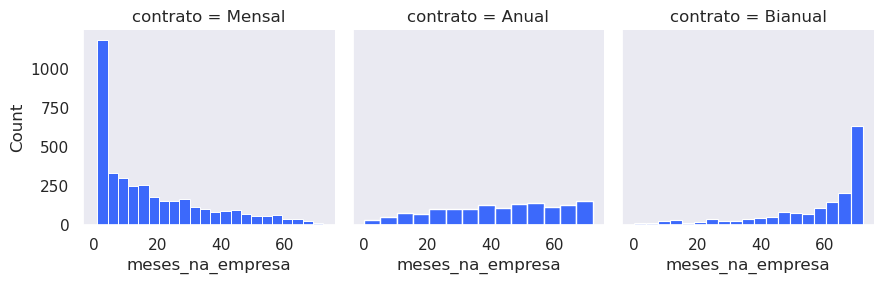

In [10]:
g = sns.FacetGrid(df_churn, col="contrato")
g.map_dataframe(sns.histplot, x="meses_na_empresa")

plt.show()

Grids mais elaborados podem ser criados. Por exemplo, com o parâmetro `hue`, podemos separar os dados de acordo com a variável `churn`. Dessa forma, podemos comparar a distribuição da variável `meses_na_empresa` de acordo com o tipo de contrato e se o cliente cancelou o serviço no mês anterior.

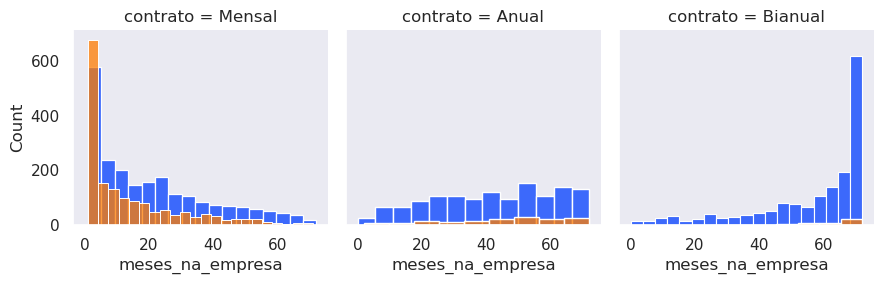

In [11]:
g = sns.FacetGrid(df_churn, col="contrato", hue="churn")
g.map_dataframe(sns.histplot, x="meses_na_empresa")

plt.show()

Outra combinação é utilizando o parâmetro `row` para separar os dados de acordo com a variável `churn`. Dessa forma, podemos comparar a distribuição da variável `meses_na_empresa` de acordo com se o cliente cancelou o serviço no mês anterior e o tipo de contrato.

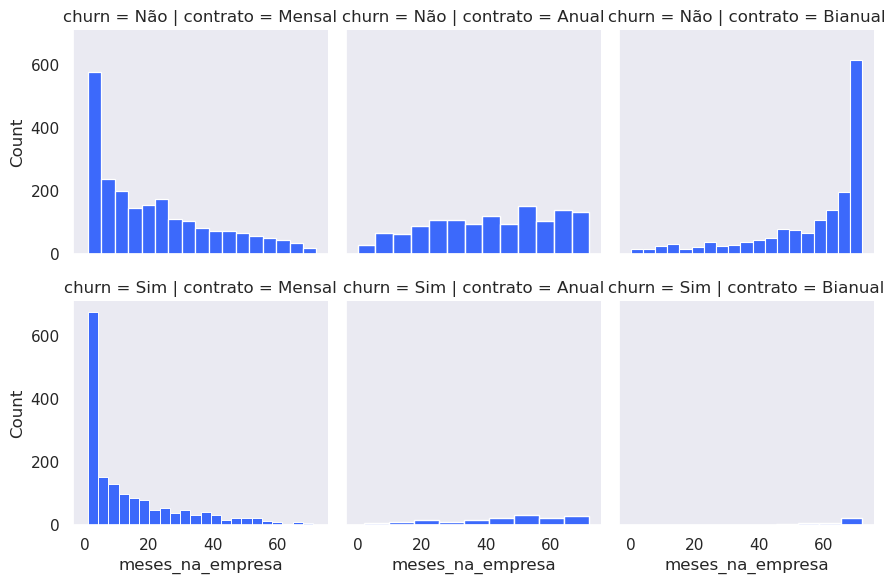

In [12]:
g = sns.FacetGrid(df_churn, col="contrato", row="churn")
g.map_dataframe(sns.histplot, x="meses_na_empresa")

plt.show()

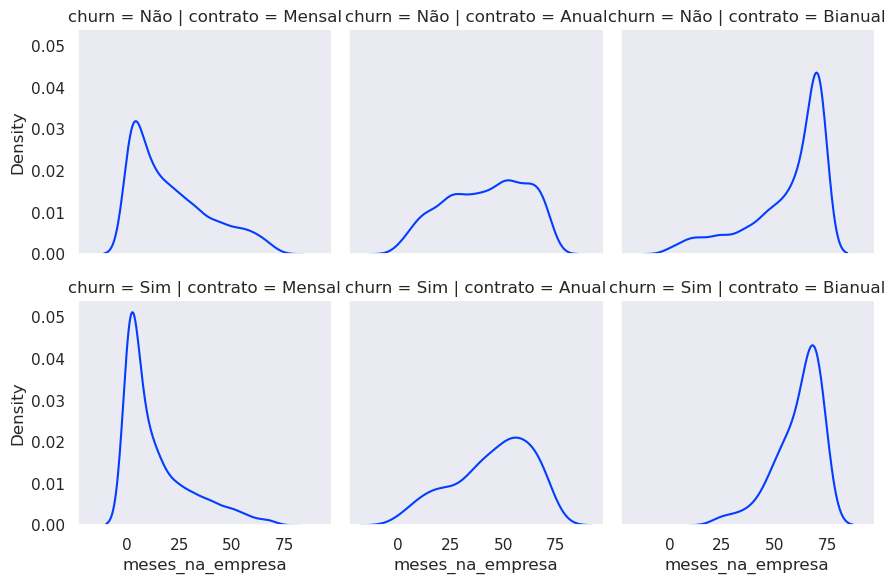

In [13]:
g = sns.FacetGrid(df_churn, col="contrato", row="churn")
g.map_dataframe(sns.kdeplot, x="meses_na_empresa")

plt.show()

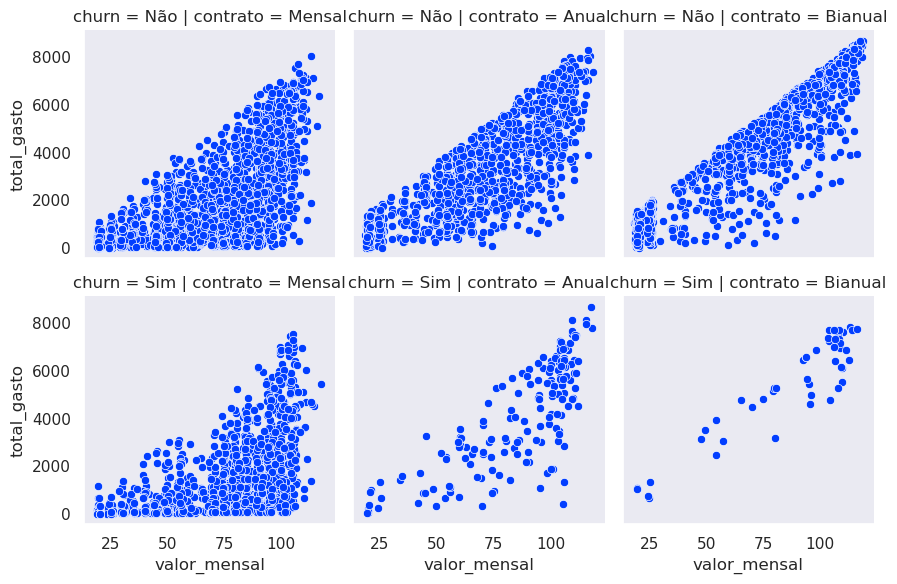

In [16]:
g = sns.FacetGrid(df_churn, col="contrato", row="churn")
g.map_dataframe(sns.scatterplot, x="valor_mensal", y="total_gasto")

plt.show()

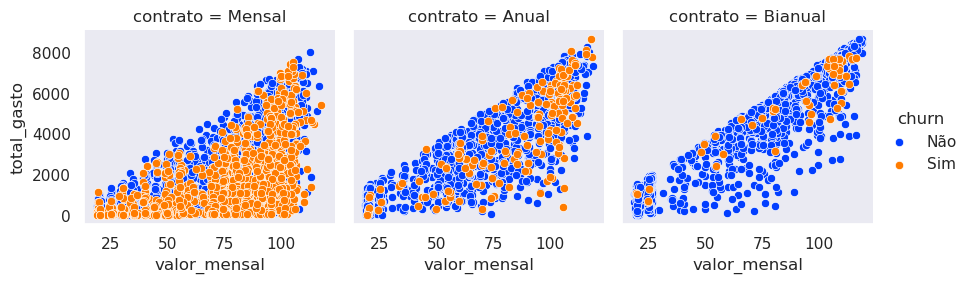

In [18]:
g = sns.FacetGrid(df_churn, col="contrato", hue="churn")
g.map_dataframe(sns.scatterplot, x="valor_mensal", y="total_gasto")

g.add_legend()

plt.show()